# Visualization - E-commerce & Retail

Notebook nay truc quan hoa ket qua pipeline cho de tai nhom 1:
- RFM Customer Segmentation
- (Optional) Market Basket Analysis

In [1]:
from pathlib import Path
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
RFM_SEGMENT_PATH = ROOT / 'data/3_curated/results/rfm/customer_segments'
RFM_SUMMARY_PATH = ROOT / 'data/3_curated/results/rfm/segment_summary'
MBA_RULES_PATH = ROOT / 'data/3_curated/results/mba/association_rules'

print('ROOT:', ROOT)
print('RFM segment path exists:', RFM_SEGMENT_PATH.exists())
print('RFM summary path exists:', RFM_SUMMARY_PATH.exists())
print('MBA rules path exists:', MBA_RULES_PATH.exists())

ROOT: /mnt/c/Users/KMN12/final-bigdata-project-nhom9
RFM segment path exists: True
RFM summary path exists: True
MBA rules path exists: False


In [3]:
rfm_segments = pd.read_parquet(RFM_SEGMENT_PATH)
rfm_summary = pd.read_parquet(RFM_SUMMARY_PATH)

display(rfm_segments.head())
display(rfm_summary.sort_values('business_score', ascending=False))

,segment,CustomerID,recency_days,frequency,monetary,segment_label
0,0,12847,22,2,1636.90,Regular
1,0,13610,12,14,2175.88,Regular
2,0,13192,95,6,2558.58,Regular
3,0,15555,12,36,12112.35,Regular
4,0,14157,19,5,1002.78,Regular


,segment,customers,avg_recency_days,avg_frequency,avg_monetary,recency_score,frequency_score,monetary_score,business_score,segment_label
3,3,2,0.50,148.00,568712.09,0.000000,1.000000,1.000000,0.7000,Potential Loyalist
2,2,26,20.54,131.88,116621.85,0.333333,0.666667,0.666667,0.5667,Potential Loyalist
0,0,3843,66.00,7.49,3132.38,0.666667,0.333333,0.333333,0.4333,Regular
1,1,2007,461.65,2.21,765.38,1.000000,0.000000,0.000000,0.3000,At Risk


## 1) Distribution of customer segments

/tmp/ipykernel_17324/366801944.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=segment_counts, x='segment_label', y='customers', palette='Set2')


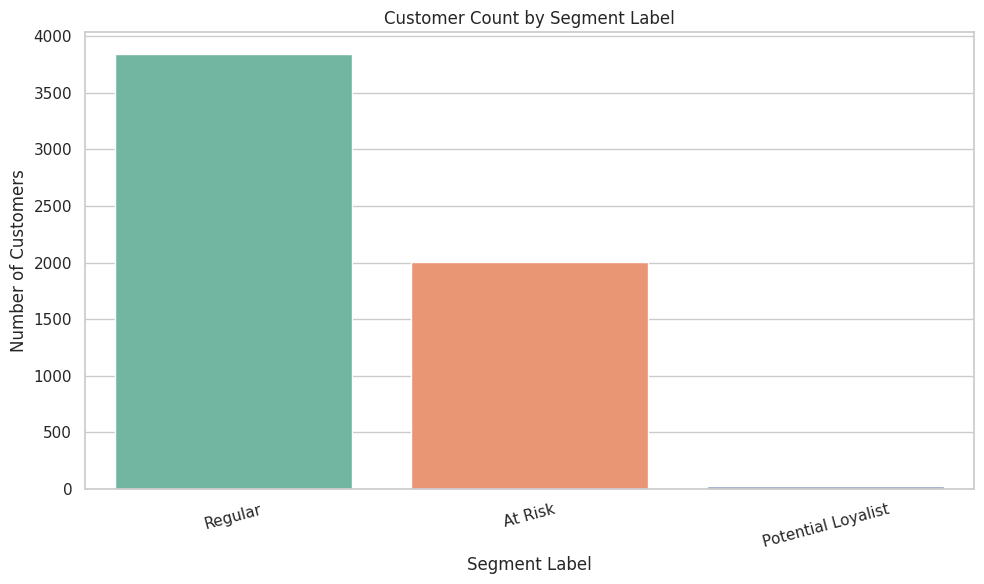

In [ ]:
segment_counts = (
    rfm_segments['segment_label']
    .value_counts()
    .rename_axis('segment_label')
    .reset_index(name='customers')
)

ax = sns.barplot(
    data=segment_counts,
    x="segment_label",
    y="customers",
    hue="segment_label",
    palette="Set2",
    legend=False
)

ax.set_title('Customer Count by Segment Label')
ax.set_xlabel('Segment Label')
ax.set_ylabel('Number of Customers')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

## 2) RFM metrics by segment

/tmp/ipykernel_17324/789322100.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


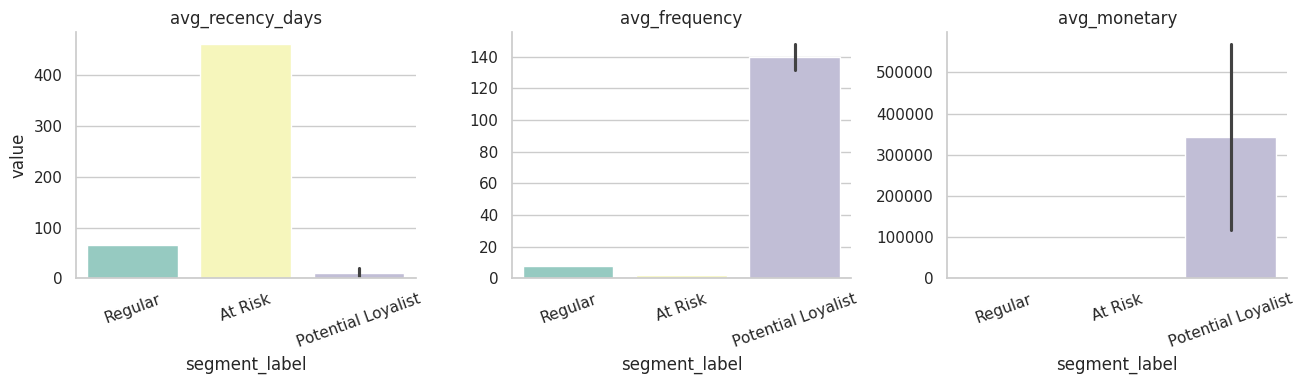

In [5]:
metrics_long = rfm_summary.melt(
    id_vars=['segment_label'],
    value_vars=['avg_recency_days', 'avg_frequency', 'avg_monetary'],
    var_name='metric',
    value_name='value'
)

g = sns.catplot(
    data=metrics_long,
    x='segment_label',
    y='value',
    col='metric',
    kind='bar',
    sharey=False,
    palette='Set3',
    height=4,
    aspect=1.1
)
g.set_titles('{col_name}')
for ax in g.axes.flat:
    ax.tick_params(axis='x', rotation=20)
plt.tight_layout()
plt.show()

## 3) Optional: Market Basket rules (if available)

/tmp/ipykernel_17324/3220520688.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_rules, x='confidence', y='rule', palette='viridis')


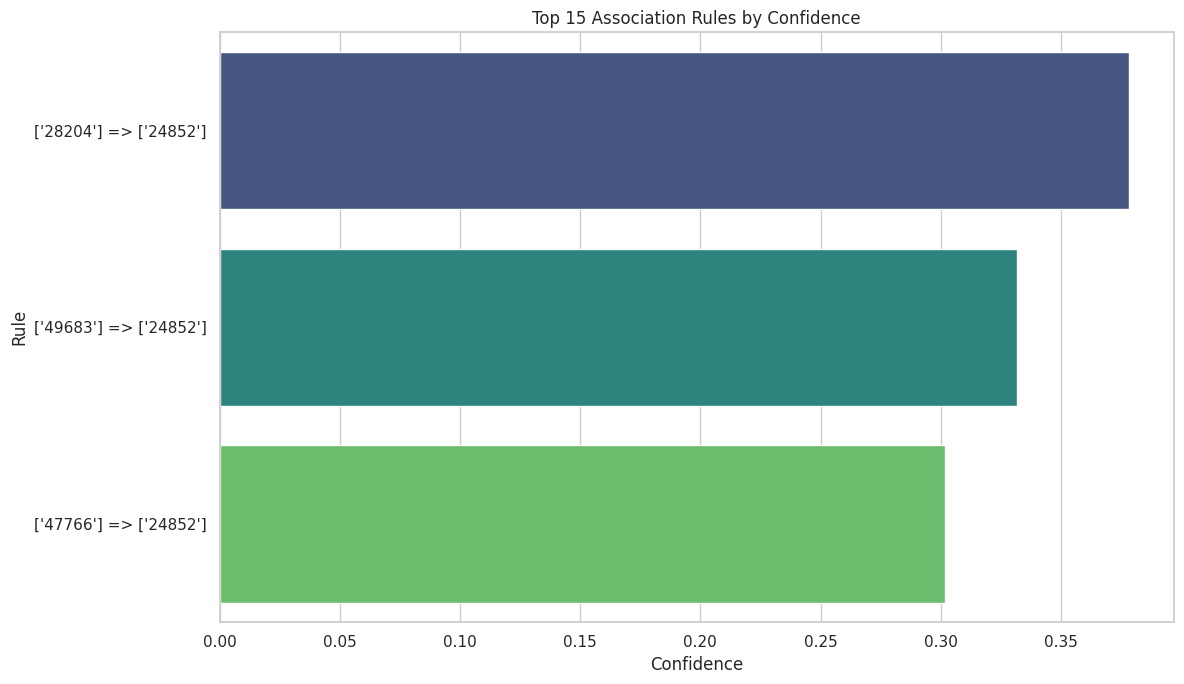

In [8]:
if MBA_RULES_PATH.exists():
    mba_rules = pd.read_parquet(MBA_RULES_PATH)
    top_rules = mba_rules.sort_values('confidence', ascending=False).head(15).copy()
    top_rules['rule'] = top_rules['antecedent'].astype(str) + ' => ' + top_rules['consequent'].astype(str)

    plt.figure(figsize=(12, 7))
    sns.barplot(data=top_rules, x='confidence', y='rule', palette='viridis')
    plt.title('Top 15 Association Rules by Confidence')
    plt.xlabel('Confidence')
    plt.ylabel('Rule')
    plt.tight_layout()
    plt.show()
else:
    print('MBA association rules not found. Run: python3 src/main_pipeline.py --project mba --step all')